# Assignment 2 - Geopandas

Create a map that visualizes the preferences of cities/municipalities between Jollibee and Mcdonalds in 'Metropolitan Manila'. Your map should distinctly show:
1. The locations of the Jollibee and Mcdonalds Establishments
1. The "preference" between the two
1. The bottom two cities in terms of number of restaurants per population

In [38]:
import psycopg2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import warnings
warnings.filterwarnings("ignore")
import contextily as ctx

In [39]:
conn = psycopg2.connect(dbname="postgis", 
                 user="gsa2022", 
                 password="g5!V%T1Vmd", 
                 host="192.168.212.99", 
                 port=32771)

In [40]:
# Your Code Here
df_points = gpd.read_postgis('''
    SELECT p.name, p.way AS geometry
    FROM public.ph_point p
    JOIN gadm.ph g ON st_within(p.way, g.geom)
    WHERE g.name_1 = 'Metropolitan Manila'
    AND (p.name ILIKE '%jollibee%' OR p.name ILIKE '%mcdonald%')
''', conn, geom_col='geometry')

In [41]:
df_points

,name,geometry
0,Jollibee,POINT (121.0451 14.38967)
1,Jollibee,POINT (121.04576 14.37746)
2,McDonald's,POINT (121.04599 14.37776)
3,McDonald's,POINT (121.04504 14.39448)
4,Jollibee,POINT (121.0383 14.39326)
...,...,...
403,McDonalds C&B Mall,POINT (121.11579 14.65034)
404,McDonald's,POINT (121.11661 14.65011)
405,jollibee,POINT (121.11336 14.65931)
406,Jollibee,POINT (121.11345 14.65943)


In [42]:
df_points['brand'] = np.where(
    df_points['name'].str.contains('ollibee', case=False), 
    'Jollibee', 
    'McDonald\'s'
)

In [43]:
gdf_cities = gpd.read_postgis('''
    SELECT g.name_2, g.geom AS geometry
    FROM gadm.ph g
    WHERE g.name_1 = 'Metropolitan Manila'
''', conn, geom_col='geometry')

In [44]:
gdf_cities

,name_2,geometry
0,Pateros,"MULTIPOLYGON (((121.06864 14.53992, 121.06883 ..."
1,Quezon City,"MULTIPOLYGON (((121.01576 14.6061, 121.01511 1..."
2,Mandaluyong,"MULTIPOLYGON (((121.05405 14.57747, 121.05408 ..."
3,Manila,"MULTIPOLYGON (((120.99142 14.56218, 120.98849 ..."
4,Marikina,"MULTIPOLYGON (((121.07346 14.61962, 121.07432 ..."
5,Muntinlupa,"MULTIPOLYGON (((121.02339 14.3576, 121.02313 1..."
6,Kalookan City,"MULTIPOLYGON (((121.02068 14.71426, 121.02071 ..."
7,Las Piñas,"MULTIPOLYGON (((120.97972 14.49306, 120.98 14...."
8,Makati City,"MULTIPOLYGON (((121.06578 14.53872, 121.06594 ..."
9,Malabon,"MULTIPOLYGON (((120.958 14.65938, 120.95796 14..."


In [45]:
# Check what columns exist in gadm.ph
pd.read_sql('''
    SELECT column_name
    FROM information_schema.columns
    WHERE table_schema = 'gadm' AND table_name = 'ph'
''', conn)

,column_name
0,gid
1,gid_0
2,name_0
3,gid_1
4,name_1
5,nl_name_1
6,gid_2
7,name_2
8,varname_2
9,nl_name_2


In [46]:
# Check what other tables exist in the database entirely
pd.read_sql('''
    SELECT table_schema, table_name
    FROM information_schema.tables
    WHERE table_schema NOT IN ('pg_catalog', 'information_schema')
    ORDER BY table_schema, table_name
''', conn)

,table_schema,table_name
0,gadm,adm0
1,gadm,adm1
2,gadm,adm2
3,gadm,adm3
4,gadm,adm4
5,gadm,adm5
6,gadm,au
7,gadm,ph
8,gadm,ph_brgy
9,gadm,ph_hum


In [47]:
population = {
    'Manila': 1846641, 'Quezon City': 2960048, 'Caloocan': 1661584,
    'Las Pinas': 606293, 'Makati City': 582602, 'Malabon': 365525,
    'Mandaluyong': 425758, 'Marikina': 456059, 'Muntinlupa': 543445,
    'Navotas': 249463, 'Paranaque': 689992, 'Pasay City': 440656,
    'Pasig City': 803159, 'Pateros': 64167, 'San Juan': 122180,
    'Taguig': 886722, 'Valenzuela': 714978
}
gdf_cities['population'] = gdf_cities['name_2'].map(population)

In [48]:
joined = gpd.sjoin(df_points, gdf_cities[['name_2', 'geometry', 'population']], 
                   how='left', predicate='within')

In [49]:
counts = joined.groupby(['name_2', 'brand']).size().unstack(fill_value=0).reset_index()
counts.columns.name = None

In [50]:
for col in ['Jollibee', "McDonald's"]:
    if col not in counts.columns:
        counts[col] = 0

In [51]:
gdf_cities = gdf_cities.merge(counts, on='name_2', how='left').fillna(0)

In [52]:
gdf_cities['total'] = gdf_cities['Jollibee'] + gdf_cities["McDonald's"]
gdf_cities['preference'] = gdf_cities['Jollibee'] - gdf_cities["McDonald's"]
gdf_cities['restaurants_per_pop'] = (gdf_cities['total'] / gdf_cities['population']) * 10000

In [53]:
bottom2 = gdf_cities.nsmallest(2, 'restaurants_per_pop')
print(bottom2[['name_2', 'total', 'population', 'restaurants_per_pop']])

     name_2  total  population  restaurants_per_pop
10  Navotas    0.0    249463.0             0.000000
15   Taguig    9.0    886722.0             0.101497


In [54]:
gdf_cities = gdf_cities.to_crs(epsg=3857)
df_points = df_points.to_crs(epsg=3857)
bottom2 = bottom2.to_crs(epsg=3857)

jollibee_pts = df_points[df_points['brand'] == 'Jollibee']
mcdo_pts = df_points[df_points['brand'] == "McDonald's"]

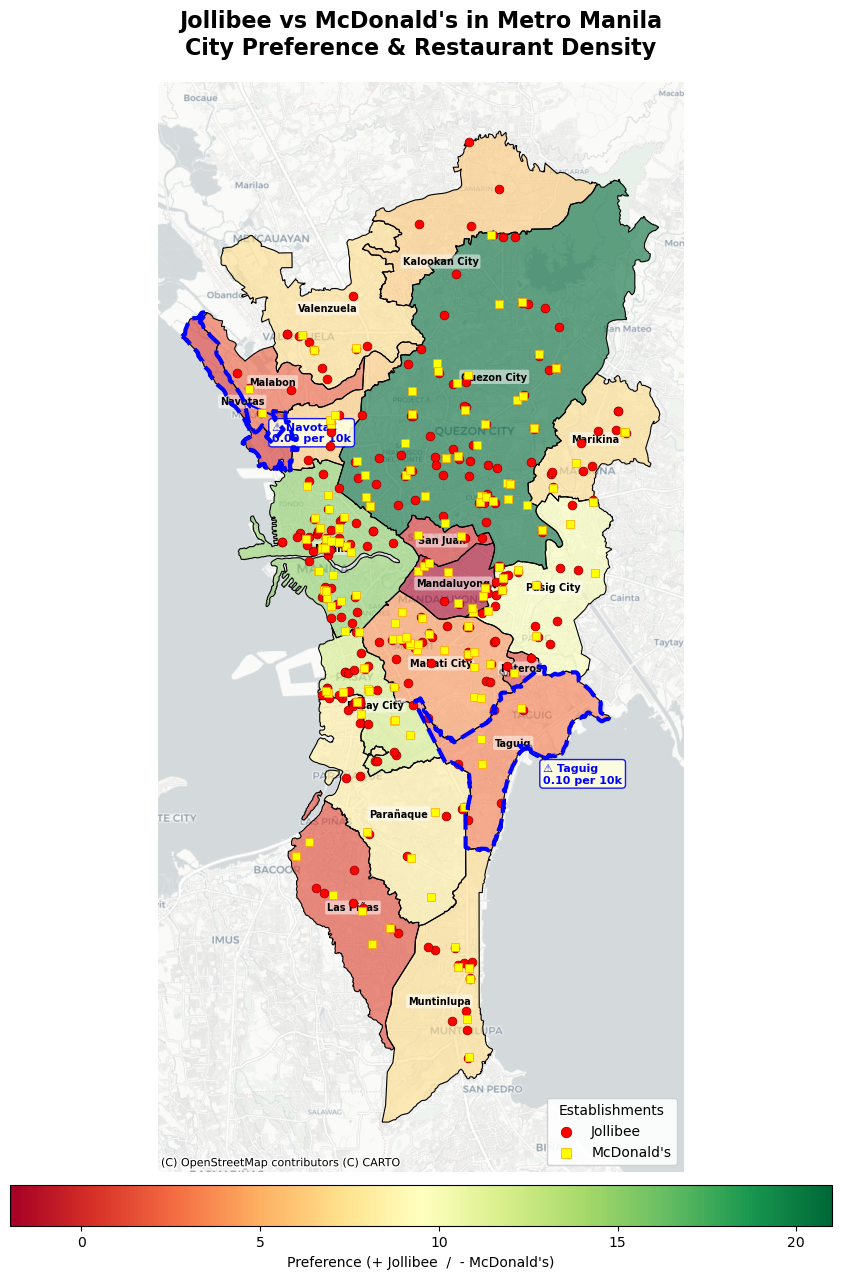

In [55]:
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

# Layer 1 — City preference choropleth
gdf_cities.plot(
    ax=ax,
    column='preference',
    cmap='RdYlGn',       # Red = McDonald's dominant, Green = Jollibee dominant
    alpha=0.6,
    legend=True,
    legend_kwds={
        'label': 'Preference (+ Jollibee  /  - McDonald\'s)',
        'orientation': 'horizontal',
        'shrink': 0.6,
        'pad': 0.01
    }
)

# Layer 2 — City borders
gdf_cities.boundary.plot(ax=ax, color='black', linewidth=0.8)

# Layer 3 — Jollibee locations
jollibee_pts.plot(ax=ax, color='red', markersize=40, marker='o', 
                  label='Jollibee', zorder=5, edgecolors='darkred', linewidth=0.5)

# Layer 4 — McDonald's locations
mcdo_pts.plot(ax=ax, color='yellow', markersize=40, marker='s', 
              label="McDonald's", zorder=5, edgecolors='orange', linewidth=0.5)

# Layer 5 — Highlight bottom 2 cities
bottom2.plot(ax=ax, color='none', edgecolor='blue', linewidth=3, 
             linestyle='--', zorder=6)

# Layer 6 — City name labels
for _, row in gdf_cities.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        row['name_2'],
        xy=(centroid.x, centroid.y),
        ha='center', va='center',
        fontsize=7, fontweight='bold', color='black',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.5, ec='none')
    )

# Layer 7 — Bottom 2 labels
for _, row in bottom2.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        f"⚠ {row['name_2']}\n{row['restaurants_per_pop']:.2f} per 10k",
        xy=(centroid.x, centroid.y),
        xytext=(centroid.x + 1500, centroid.y - 2000),
        fontsize=8, color='blue', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='blue', lw=1.5),
        bbox=dict(boxstyle='round', fc='lightyellow', ec='blue', alpha=0.9)
    )

# Layer 8 — Basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)

# Legend and titles
ax.legend(loc='lower right', fontsize=10, framealpha=0.9,
          markerscale=1.2, title='Establishments', title_fontsize=10)
ax.set_title('Jollibee vs McDonald\'s in Metro Manila\nCity Preference & Restaurant Density',
             fontsize=16, fontweight='bold', pad=20)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('metro_manila_fastfood_map.png', dpi=150, bbox_inches='tight')
plt.show()